In [1]:
!pip install datasets transformers torch pandas matplotlib scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\SaiVamshiGudem\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

C:\Users\SaiVamshiGudem\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset = load_dataset("stanfordnlp/imdb")

In [4]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [5]:
train_data = dataset["train"].shuffle(seed=42).select(range(2000))

validation_data = dataset["test"].shuffle(seed=42).select(range(500))

test_data = dataset["test"].shuffle(seed=100).select(range(500))

In [6]:
train_df = train_data.to_pandas()

validation_df = validation_data.to_pandas()

test_df = test_data.to_pandas()

In [7]:
print("Training Dataset Shape :", train_df.shape)

print("Validation Dataset Shape :", validation_df.shape)

print("Testing Dataset Shape :", test_df.shape)


Training Dataset Shape : (2000, 2)
Validation Dataset Shape : (500, 2)
Testing Dataset Shape : (500, 2)


In [8]:
print("Training Dataset")

display(train_df.head())

Training Dataset


,text,label
0,There is no relation at all between Fortier an...,1
1,This movie is a great. The plot is very true t...,1
2,"George P. Cosmatos' ""Rambo: First Blood Part I...",0
3,In the process of trying to establish the audi...,1
4,"Yeh, I know -- you're quivering with excitemen...",0


In [9]:
label_mapping = {

    0: "Negative",

    1: "Positive"

}

print("Label Mapping")

for key, value in label_mapping.items():

    print(key, "=", value)

Label Mapping
0 = Negative
1 = Positive


In [10]:
for i in range(3):

    review = train_df.iloc[i]["text"]

    label = train_df.iloc[i]["label"]

    print("=" * 70)

    print("Review Number :", i + 1)

    print("Sentiment :", label_mapping[label])

    print()

    print(review[:500])

    print()


Review Number : 1
Sentiment : Positive

There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks Am

Review Number : 2
Sentiment : Positive

This movie is a great. The plot is very true to the book which is a classic written by Mark Twain. The movie starts of with a scene where Hank sings a song with a bunch of kids called "when you stub your toe on the moon" It reminds me of Sinatra's song High Hopes, it is fun and inspirational. The Music is great throughout and my favorite song is sung by the King, Hank (bing Crosby) and Sir "Saggy" Sagamore. OVerall

In [11]:
print("Missing Values")

print(train_df.isnull().sum())

Missing Values
text     0
label    0
dtype: int64


In [12]:
duplicates = train_df.duplicated().sum()

print("Duplicate Reviews :", duplicates)

Duplicate Reviews : 0


In [13]:
sentiment_counts = train_df["label"].value_counts().sort_index()

print("Sentiment Distribution")

print(sentiment_counts)

Sentiment Distribution
label
0    1000
1    1000
Name: count, dtype: int64


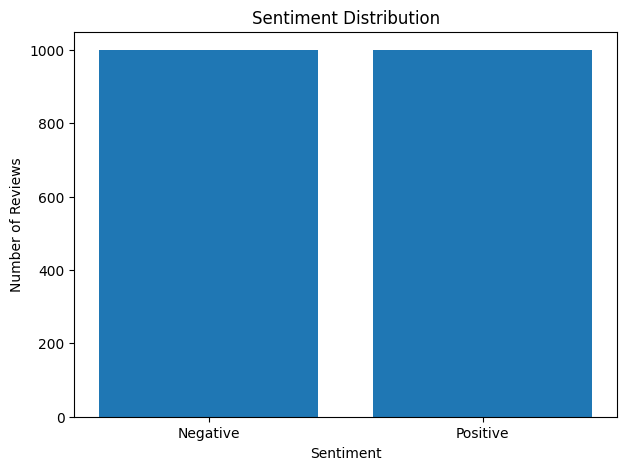

In [14]:
sentiment_names = [

    label_mapping[label]

    for label in sentiment_counts.index

]

plt.figure(figsize=(7, 5))

plt.bar(

    sentiment_names,

    sentiment_counts.values

)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()


In [15]:
train_df["review_length"] = train_df["text"].apply(

    lambda review: len(review.split())

)

print(train_df["review_length"].describe())

count    2000.00000
mean      228.43450
std       168.67367
min        12.00000
25%       127.00000
50%       172.00000
75%       268.25000
max      1005.00000
Name: review_length, dtype: float64


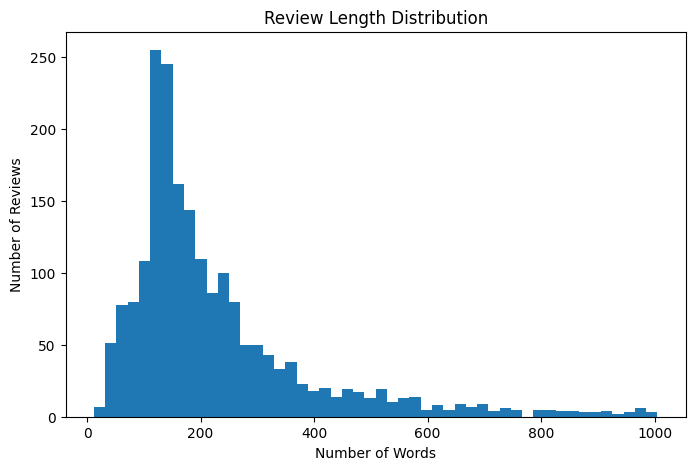

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(

    train_df["review_length"],

    bins=50

)

plt.title("Review Length Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Number of Reviews")

plt.show()


In [17]:
average_length = train_df.groupby(

    "label"

)["review_length"].mean()

print("Average Review Length")

for label, length in average_length.items():

    print(

        label_mapping[label],

        ":",

        round(length, 2),

        "words"

    )



Average Review Length
Negative : 224.71 words
Positive : 232.16 words


In [18]:
longest_review_index = train_df["review_length"].idxmax()

shortest_review_index = train_df["review_length"].idxmin()

print("Longest Review")

print(

    train_df.loc[

        longest_review_index,

        "review_length"

    ],

    "words"

)

print()

print("Shortest Review")

print(

    train_df.loc[

        shortest_review_index,

        "review_length"

    ],

    "words"

)


Longest Review
1005 words

Shortest Review
12 words


In [19]:
train_df.drop(

    "review_length",

    axis=1,

    inplace=True

)


In [20]:
print("Project       : Sentiment Analysis Using DistilBERT")

print("Problem Type  : Binary Classification")

print("Training Data :", len(train_df))

print("Validation Data :", len(validation_df))

print("Testing Data  :", len(test_df))

print()

print("Classes:")

print("0 -> Negative")

print("1 -> Positive")

print()

print("CPU-Friendly Dataset Configuration")

print("Maximum Training Samples : 2000")

print("Validation Samples       : 500")

print("Testing Samples          : 500")

print()


Project       : Sentiment Analysis Using DistilBERT
Problem Type  : Binary Classification
Training Data : 2000
Validation Data : 500
Testing Data  : 500

Classes:
0 -> Negative
1 -> Positive

CPU-Friendly Dataset Configuration
Maximum Training Samples : 2000
Validation Samples       : 500
Testing Samples          : 500



In [21]:
import re
import torch

from datasets import Dataset

from transformers import AutoTokenizer

from torch.utils.data import DataLoader

In [22]:
def clean_text(text):

    text = re.sub(r"<br\s*/?>", " ", text)

    text = re.sub(r"\s+", " ", text)

    text = text.strip()

    return text

In [23]:
train_df["text"] = train_df["text"].apply(clean_text)

validation_df["text"] = validation_df["text"].apply(clean_text)

test_df["text"] = test_df["text"].apply(clean_text)


print("Text Cleaning Completed Successfully")


Text Cleaning Completed Successfully


In [24]:
print("Sample Cleaned Review:\n")

print(train_df.iloc[0]["text"][:500])

Sample Cleaned Review:

There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. Fortier's plot are far more complicated... Fortier looks more like Prime Suspect, if we have to spot similarities... The main character is weak and weirdo, but have "clairvoyance". People like to compare, to judge, to evaluate. How about just enjoying? Funny thing too, people writing Fortier looks Am


In [25]:
train_dataset = Dataset.from_pandas(train_df)

validation_dataset = Dataset.from_pandas(validation_df)

test_dataset = Dataset.from_pandas(test_df)


print("Train Dataset Size :", len(train_dataset))

print("Validation Dataset Size :", len(validation_dataset))

print("Test Dataset Size :", len(test_dataset))

Train Dataset Size : 2000
Validation Dataset Size : 500
Test Dataset Size : 500


In [26]:
MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(

    MODEL_NAME

)

print("Tokenizer Loaded Successfully")

Tokenizer Loaded Successfully


In [27]:
sample_text = train_df.iloc[0]["text"]

tokens = tokenizer.tokenize(

    sample_text[:200]

)

token_ids = tokenizer.convert_tokens_to_ids(

    tokens

)

print("Original Text:\n")

print(sample_text[:200])

print("\nTokens:\n")

print(tokens[:30])

print("\nToken IDs:\n")

print(token_ids[:30])


Original Text:

There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F

Tokens:

['there', 'is', 'no', 'relation', 'at', 'all', 'between', 'fort', '##ier', 'and', 'profile', '##r', 'but', 'the', 'fact', 'that', 'both', 'are', 'police', 'series', 'about', 'violent', 'crimes', '.', 'profile', '##r', 'looks', 'crisp', '##y', ',']

Token IDs:

[2045, 2003, 2053, 7189, 2012, 2035, 2090, 3481, 3771, 1998, 6337, 2099, 2021, 1996, 2755, 2008, 2119, 2024, 2610, 2186, 2055, 6355, 6997, 1012, 6337, 2099, 3504, 15594, 2100, 1010]


In [28]:
MAX_LENGTH = 128

In [29]:
def tokenize_function(examples):

    return tokenizer(

        examples["text"],

        truncation=True,

        padding="max_length",

        max_length=MAX_LENGTH

    )



In [30]:
train_dataset = train_dataset.map(

    tokenize_function,

    batched=True

)


Map: 100%|████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 2898.66 examples/s]


In [31]:
validation_dataset = validation_dataset.map(

    tokenize_function,

    batched=True

)

Map: 100%|██████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 4266.09 examples/s]


In [32]:
test_dataset = test_dataset.map(

    tokenize_function,

    batched=True

)

print("All Datasets Tokenized Successfully")


Map: 100%|██████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 3870.98 examples/s]

All Datasets Tokenized Successfully


In [33]:
columns_to_remove = [

    "text"

]

In [34]:
for dataset_name in [

    train_dataset,

    validation_dataset,

    test_dataset

]:

    if "__index_level_0__" in dataset_name.column_names:

        columns_to_remove.append(

            "__index_level_0__"

        )


In [35]:
for column in columns_to_remove:

    if column in train_dataset.column_names:

        train_dataset = train_dataset.remove_columns(

            column

        )

    if column in validation_dataset.column_names:

        validation_dataset = validation_dataset.remove_columns(

            column

        )

    if column in test_dataset.column_names:

        test_dataset = test_dataset.remove_columns(

            column

        )


In [36]:
columns = [

    "input_ids",

    "attention_mask",

    "label"

]

train_dataset.set_format(

    type="torch",

    columns=columns

)

validation_dataset.set_format(

    type="torch",

    columns=columns

)

test_dataset.set_format(

    type="torch",

    columns=columns

)

print("PyTorch Format Applied Successfully")



PyTorch Format Applied Successfully


In [37]:
BATCH_SIZE = 8


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0

)


validation_loader = DataLoader(

    validation_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0

)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0

)


print("DataLoaders Created Successfully")



DataLoaders Created Successfully


In [38]:
print()

print("Training Batches :", len(train_loader))

print("Validation Batches :", len(validation_loader))

print("Testing Batches :", len(test_loader))




Training Batches : 250
Validation Batches : 63
Testing Batches : 63


In [39]:
batch = next(

    iter(train_loader)

)


print("Batch Keys:")

print(batch.keys())

print()

print("Input IDs Shape:")

print(batch["input_ids"].shape)

print()

print("Attention Mask Shape:")

print(batch["attention_mask"].shape)

print()

print("Labels Shape:")

print(batch["label"].shape)


Batch Keys:
dict_keys(['label', 'input_ids', 'attention_mask'])

Input IDs Shape:
torch.Size([8, 128])

Attention Mask Shape:
torch.Size([8, 128])

Labels Shape:
torch.Size([8])


In [40]:
example_ids = batch["input_ids"][0]

example_tokens = tokenizer.convert_ids_to_tokens(

    example_ids

)

print()

print("First 30 Tokens:")

print(example_tokens[:30])

print()

print("Label:")

print(

    batch["label"][0].item(),

    "-",

    label_mapping[batch["label"][0].item()]

)



First 30 Tokens:
['[CLS]', 'this', 'has', 'to', 'be', 'one', 'of', 'my', 'favourite', 'movies', 'of', 'all', 'time', '.', 'the', 'dialogue', ',', 'with', 'the', 'constant', 'use', 'of', 'pun', '##s', 'is', 'very', 'tight', ',', 'the', 'cast']

Label:
1 - Positive


In [41]:
device = torch.device(

    "cuda" if torch.cuda.is_available() else "cpu"

)

print()

print("Running On :", device)


Running On : cpu


In [42]:
print("Text Cleaning Completed")

print("DistilBERT Tokenizer Loaded")

print("Maximum Token Length :", MAX_LENGTH)

print("Batch Size :", BATCH_SIZE)

print("Training Samples :", len(train_dataset))

print("Validation Samples :", len(validation_dataset))

print("Testing Samples :", len(test_dataset))

print()

print("Created:")

print("✔ input_ids")

print("✔ attention_mask")

print("✔ labels")

print("✔ train_loader")

print("✔ validation_loader")

print("✔ test_loader")

print()


Text Cleaning Completed
DistilBERT Tokenizer Loaded
Maximum Token Length : 128
Batch Size : 8
Training Samples : 2000
Validation Samples : 500
Testing Samples : 500

Created:
✔ input_ids
✔ attention_mask
✔ labels
✔ train_loader
✔ validation_loader
✔ test_loader



Running On : cpu


Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 5163.30it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



DistilBERT Model Loaded Successfully
Model Name : distilbert-base-uncased

Epochs : 2
Training Batches : 250
Total Training Steps : 500

Model Save Path :
C:\Users\SaiVamshiGudem\Desktop\Projects\sentiment_bert_model

EPOCH 1/2
Batch 50/250 - Loss: 0.5541
Batch 100/250 - Loss: 0.8118
Batch 150/250 - Loss: 0.4564
Batch 200/250 - Loss: 0.5276
Batch 250/250 - Loss: 0.1745

Training Loss     : 0.4643
Validation Loss   : 0.3605
Validation Accuracy: 83.6 %


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.07it/s]



BEST MODEL SAVED
Validation Loss : 0.3605

EPOCH 2/2
Batch 50/250 - Loss: 0.1640
Batch 100/250 - Loss: 0.4681
Batch 150/250 - Loss: 0.0818
Batch 200/250 - Loss: 0.2672
Batch 250/250 - Loss: 0.1244

Training Loss     : 0.2506
Validation Loss   : 0.3693
Validation Accuracy: 83.2 %

TRAINING COMPLETED

Best Validation Loss : 0.3605

Model saved at:
C:\Users\SaiVamshiGudem\Desktop\Projects\sentiment_bert_model

SAVED MODEL FILES
- config.json
- model.safetensors
- tokenizer.json
- tokenizer_config.json


Loading weights: 100%|█████████████████████████████████████████████████████████████| 104/104 [00:00<00:00, 1951.15it/s]


Best Saved DistilBERT Model Loaded Successfully
Saved Tokenizer Loaded Successfully


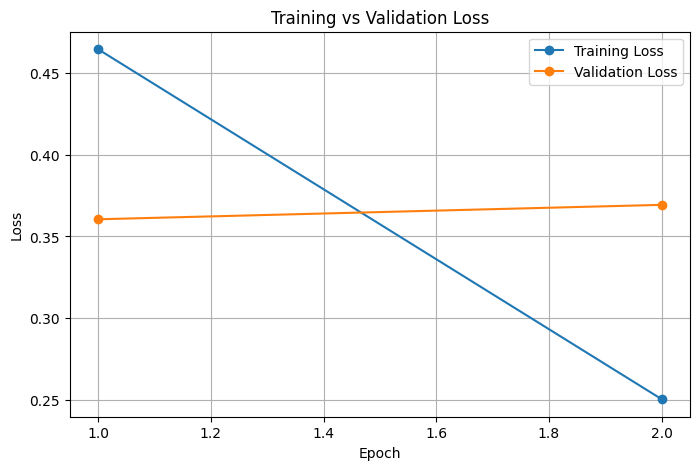

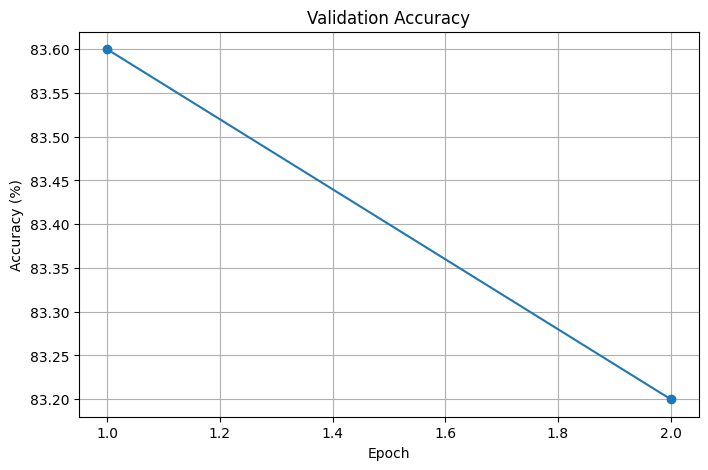


Testing Completed Successfully

TEST RESULTS
Accuracy  : 85.6 %
Precision : 85.45 %
Recall    : 87.4 %
F1 Score  : 86.42 %

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85       238
    Positive       0.85      0.87      0.86       262

    accuracy                           0.86       500
   macro avg       0.86      0.86      0.86       500
weighted avg       0.86      0.86      0.86       500



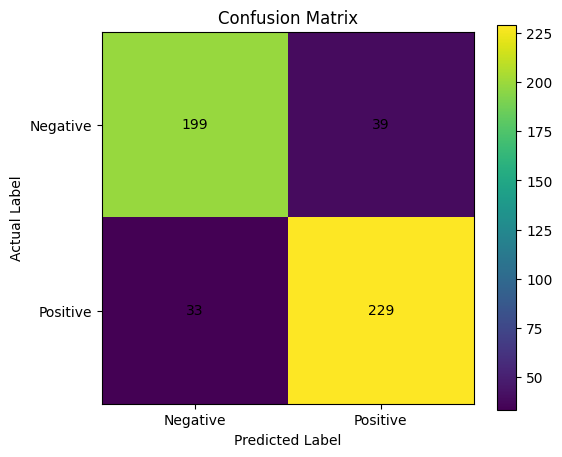


CUSTOM PREDICTIONS

Review 1:
{'Sentiment': 'Positive', 'Confidence': 93.52}

Review 2:
{'Sentiment': 'Negative', 'Confidence': 96.23}

END-TO-END SENTIMENT ANALYSIS PROJECT COMPLETED

✔ IMDb Dataset Loaded
✔ CPU-Friendly Dataset Sampling
✔ Text Cleaning Completed
✔ DistilBERT Tokenization
✔ Input IDs Created
✔ Attention Masks Created
✔ DataLoaders Created
✔ DistilBERT Fine-Tuned
✔ Best Model Saved
✔ Validation Evaluated
✔ Accuracy Calculated
✔ Precision Calculated
✔ Recall Calculated
✔ F1 Score Calculated
✔ Confusion Matrix Generated
✔ Classification Report Generated
✔ Custom Sentiment Prediction Created

MODEL SAVE LOCATION:
C:\Users\SaiVamshiGudem\Desktop\Projects\sentiment_bert_model

PROJECT COMPLETED SUCCESSFULLY!


In [57]:
# ============================================================
# DISTILBERT MODEL TRAINING & EVALUATION
# PROJECT : SENTIMENT ANALYSIS USING BERT
# MODEL : DISTILBERT
# ============================================================


# ============================================================
# SECTION 1 : IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import torch
import torch.nn as nn

from transformers import (
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.optim import AdamW

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


# ============================================================
# SECTION 2 : DEFINE MODEL VARIABLES
# ============================================================

# IMPORTANT:
# MODEL_NAME = pretrained Hugging Face model
# MODEL_SAVE_PATH = local folder for your trained model

MODEL_NAME = "distilbert-base-uncased"

MODEL_SAVE_PATH = "sentiment_bert_model"

NUM_LABELS = 2


# ============================================================
# SECTION 3 : CHECK DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Running On :", device)


# ============================================================
# SECTION 4 : LOAD PRETRAINED DISTILBERT
# ============================================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

model = model.to(device)

print()
print("DistilBERT Model Loaded Successfully")
print("Model Name :", MODEL_NAME)


# ============================================================
# SECTION 5 : DEFINE OPTIMIZER
# ============================================================

optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)


# ============================================================
# SECTION 6 : TRAINING SETTINGS
# ============================================================

EPOCHS = 2

total_training_steps = len(train_loader) * EPOCHS

print()
print("Epochs :", EPOCHS)

print("Training Batches :", len(train_loader))

print("Total Training Steps :", total_training_steps)


# ============================================================
# SECTION 7 : LEARNING RATE SCHEDULER
# ============================================================

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_training_steps
)


# ============================================================
# SECTION 8 : CREATE MODEL SAVE DIRECTORY
# ============================================================

os.makedirs(
    MODEL_SAVE_PATH,
    exist_ok=True
)

print()
print("Model Save Path :")
print(os.path.abspath(MODEL_SAVE_PATH))


# ============================================================
# SECTION 9 : TRAINING HISTORY
# ============================================================

train_losses = []

validation_losses = []

validation_accuracies = []


# ============================================================
# SECTION 10 : TRAINING LOOP
# ============================================================

best_validation_loss = float("inf")


for epoch in range(EPOCHS):

    print()
    print("=" * 70)
    print(f"EPOCH {epoch + 1}/{EPOCHS}")
    print("=" * 70)


    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    model.train()

    total_train_loss = 0


    for batch_number, batch in enumerate(train_loader):

        # Move tensors to device

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["label"].to(device)


        # Clear previous gradients

        optimizer.zero_grad()


        # Forward pass

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )


        # Get loss

        loss = outputs.loss


        # Backpropagation

        loss.backward()


        # Update model parameters

        optimizer.step()


        # Update learning rate

        scheduler.step()


        # Accumulate loss

        total_train_loss += loss.item()


        # Display progress

        if (batch_number + 1) % 50 == 0:

            print(
                f"Batch {batch_number + 1}/{len(train_loader)} "
                f"- Loss: {loss.item():.4f}"
            )


    # Average training loss

    average_train_loss = (
        total_train_loss / len(train_loader)
    )

    train_losses.append(
        average_train_loss
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    total_validation_loss = 0

    validation_predictions = []

    validation_labels = []


    with torch.no_grad():

        for batch in validation_loader:

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            labels = batch["label"].to(device)


            # Forward pass

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )


            # Validation loss

            loss = outputs.loss

            total_validation_loss += loss.item()


            # Predictions

            predictions = torch.argmax(
                outputs.logits,
                dim=1
            )


            validation_predictions.extend(
                predictions.cpu().numpy()
            )

            validation_labels.extend(
                labels.cpu().numpy()
            )


    # Average validation loss

    average_validation_loss = (
        total_validation_loss / len(validation_loader)
    )

    validation_losses.append(
        average_validation_loss
    )


    # Validation accuracy

    validation_accuracy = accuracy_score(
        validation_labels,
        validation_predictions
    )

    validation_accuracies.append(
        validation_accuracy
    )


    # --------------------------------------------------------
    # DISPLAY EPOCH RESULTS
    # --------------------------------------------------------

    print()

    print("Training Loss     :",
          round(average_train_loss, 4))

    print("Validation Loss   :",
          round(average_validation_loss, 4))

    print("Validation Accuracy:",
          round(validation_accuracy * 100, 2),
          "%")


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if average_validation_loss < best_validation_loss:

        best_validation_loss = average_validation_loss


        model.save_pretrained(
            MODEL_SAVE_PATH
        )


        tokenizer.save_pretrained(
            MODEL_SAVE_PATH
        )


        print()
        print("BEST MODEL SAVED")
        print(
            "Validation Loss :",
            round(best_validation_loss, 4)
        )


# ============================================================
# SECTION 11 : TRAINING COMPLETED
# ============================================================

print()
print("=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)

print()

print("Best Validation Loss :",
      round(best_validation_loss, 4))

print()

print("Model saved at:")

print(
    os.path.abspath(MODEL_SAVE_PATH)
)


# ============================================================
# SECTION 12 : VERIFY SAVED MODEL FILES
# ============================================================

print()
print("=" * 70)
print("SAVED MODEL FILES")
print("=" * 70)

for file_name in os.listdir(MODEL_SAVE_PATH):

    print("-", file_name)


# ============================================================
# SECTION 13 : LOAD BEST SAVED MODEL
# ============================================================

# IMPORTANT:
# Load from MODEL_SAVE_PATH, NOT MODEL_NAME.

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_SAVE_PATH,
    local_files_only=True
)

model = model.to(device)

model.eval()


print()
print("Best Saved DistilBERT Model Loaded Successfully")


# ============================================================
# SECTION 14 : LOAD SAVED TOKENIZER
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_SAVE_PATH,
    local_files_only=True
)

print("Saved Tokenizer Loaded Successfully")


# ============================================================
# SECTION 15 : PLOT TRAINING VS VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, EPOCHS + 1),
    validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# SECTION 16 : PLOT VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    [accuracy * 100 for accuracy in validation_accuracies],
    marker="o"
)

plt.title("Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()


# ============================================================
# SECTION 17 : TEST MODEL
# ============================================================

test_predictions = []

test_labels = []


model.eval()


with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["label"].to(device)


        # Forward pass

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )


        # Prediction

        predictions = torch.argmax(
            outputs.logits,
            dim=1
        )


        # Store predictions

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_labels.extend(
            labels.cpu().numpy()
        )


print()
print("Testing Completed Successfully")


# ============================================================
# SECTION 18 : CALCULATE METRICS
# ============================================================

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_precision = precision_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    zero_division=0
)


# ============================================================
# SECTION 19 : DISPLAY TEST RESULTS
# ============================================================

print()
print("=" * 60)
print("TEST RESULTS")
print("=" * 60)

print(
    "Accuracy  :",
    round(test_accuracy * 100, 2),
    "%"
)

print(
    "Precision :",
    round(test_precision * 100, 2),
    "%"
)

print(
    "Recall    :",
    round(test_recall * 100, 2),
    "%"
)

print(
    "F1 Score  :",
    round(test_f1 * 100, 2),
    "%"
)


# ============================================================
# SECTION 20 : CLASSIFICATION REPORT
# ============================================================

print()
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=[
            "Negative",
            "Positive"
        ],
        zero_division=0
    )
)


# ============================================================
# SECTION 21 : CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    test_labels,
    test_predictions
)


plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title("Confusion Matrix")


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )


plt.show()


# ============================================================
# SECTION 22 : CUSTOM SENTIMENT PREDICTION
# ============================================================

def predict_sentiment(text):

    # Tokenize input

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )


    # Move tensors to device

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }


    # Evaluation mode

    model.eval()


    with torch.no_grad():

        outputs = model(
            **inputs
        )


        # Convert logits to probabilities

        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )


        # Get highest probability

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )


    sentiment = label_mapping[
        prediction.item()
    ]


    return {
        "Sentiment": sentiment,
        "Confidence": round(
            confidence.item() * 100,
            2
        )
    }


# ============================================================
# SECTION 23 : TEST CUSTOM REVIEWS
# ============================================================

review_1 = """
This movie was absolutely amazing.
The acting was excellent and the story was
interesting from beginning to end.
"""


review_2 = """
This was one of the worst movies I have ever watched.
The story was boring and the acting was terrible.
"""


print()
print("=" * 60)
print("CUSTOM PREDICTIONS")
print("=" * 60)


print()

print("Review 1:")

print(
    predict_sentiment(review_1)
)


print()

print("Review 2:")

print(
    predict_sentiment(review_2)
)


# ============================================================
# SECTION 24 : FINAL PROJECT SUMMARY
# ============================================================

print()
print("=" * 70)
print("END-TO-END SENTIMENT ANALYSIS PROJECT COMPLETED")
print("=" * 70)

print()

print("✔ IMDb Dataset Loaded")

print("✔ CPU-Friendly Dataset Sampling")

print("✔ Text Cleaning Completed")

print("✔ DistilBERT Tokenization")

print("✔ Input IDs Created")

print("✔ Attention Masks Created")

print("✔ DataLoaders Created")

print("✔ DistilBERT Fine-Tuned")

print("✔ Best Model Saved")

print("✔ Validation Evaluated")

print("✔ Accuracy Calculated")

print("✔ Precision Calculated")

print("✔ Recall Calculated")

print("✔ F1 Score Calculated")

print("✔ Confusion Matrix Generated")

print("✔ Classification Report Generated")

print("✔ Custom Sentiment Prediction Created")

print()

print("MODEL SAVE LOCATION:")

print(
    os.path.abspath(MODEL_SAVE_PATH)
)

print()

print("PROJECT COMPLETED SUCCESSFULLY!")